# Prediction multiclasse

## Importation des packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import RFE
from sklearn.utils import resample


from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

### Chargement des données

In [2]:
df = pd.read_excel('Delestage_annuelle_2019.xlsx',parse_dates=True, index_col=[0])

df.head()

,P.dispo (MW),Demande (MW),Délest par Manque Product,P. Effacée (MW),Autres P. coupée (MW),Déficit total (MW),Frequence (Hz)
Heure,,,,,,,
2019-01-01 01:00:00,636.930263,430.407707,0.0,0.0,0.0,0.0,50.109
2019-01-01 02:00:00,636.930263,406.129563,0.0,0.0,0.0,0.0,49.939
2019-01-01 03:00:00,636.930263,372.603857,0.0,0.0,0.0,0.0,50.281
2019-01-01 04:00:00,636.930263,356.614000,0.0,0.0,3.3,3.3,50.365
2019-01-01 05:00:00,636.930263,352.424888,0.0,0.0,0.0,0.0,50.199


In [3]:
df['Frequence_cat'] = df['Frequence (Hz)'].apply(
    lambda x: 1 if x > 50.3 else (2 if 49.7 <= x <= 50.3 else 3)
)

df.head()

,P.dispo (MW),Demande (MW),Délest par Manque Product,P. Effacée (MW),Autres P. coupée (MW),Déficit total (MW),Frequence (Hz),Frequence_cat
Heure,,,,,,,,
2019-01-01 01:00:00,636.930263,430.407707,0.0,0.0,0.0,0.0,50.109,2
2019-01-01 02:00:00,636.930263,406.129563,0.0,0.0,0.0,0.0,49.939,2
2019-01-01 03:00:00,636.930263,372.603857,0.0,0.0,0.0,0.0,50.281,2
2019-01-01 04:00:00,636.930263,356.614000,0.0,0.0,3.3,3.3,50.365,1
2019-01-01 05:00:00,636.930263,352.424888,0.0,0.0,0.0,0.0,50.199,2


### Visualisation de la variable cible


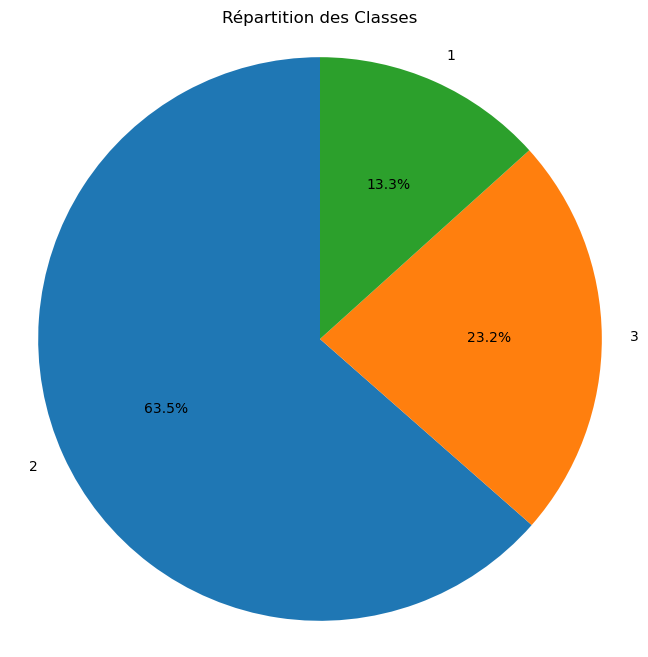

In [4]:
# Supposons une variable catégorique
counts = df["Frequence_cat"].value_counts()

# Diagramme circulaire
plt.figure(figsize=(8, 8))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%',startangle=90)
plt.title("Répartition des Classes")
plt.axis('equal')  # cercle parfait
plt.show()

In [5]:
plus_frequence = df[df.Frequence_cat == 1]

plus_frequence.describe()

,P.dispo (MW),Demande (MW),Délest par Manque Product,P. Effacée (MW),Autres P. coupée (MW),Déficit total (MW),Frequence (Hz),Frequence_cat
count,1302.000000,1302.000000,1302.0,1302.000000,1302.000000,1302.000000,1302.000000,1302.0
mean,670.555135,470.714639,0.0,0.059140,2.223479,2.282619,50.404163,1.0
std,67.196341,74.588635,0.0,0.700525,5.756229,5.799585,0.095869,0.0
min,486.850000,284.344743,0.0,0.000000,0.000000,0.000000,50.300999,1.0
25%,625.657250,412.063861,0.0,0.000000,0.000000,0.000000,50.334000,1.0
50%,671.560523,467.890680,0.0,0.000000,0.160000,0.200000,50.377000,1.0
75%,720.608062,520.663524,0.0,0.000000,2.000000,2.100000,50.443000,1.0
max,851.482417,669.361953,0.0,11.000000,72.090000,72.090000,50.961000,1.0


## Pre_traitement des données